In [16]:
import pathlib
import numpy
import pandas
import seaborn
from matplotlib import pyplot

%matplotlib inline

> PARÂMETROS

### AQUI COMEÇA MEU CÓDIGO LEGAL

In [18]:
# BUILD PATH TO DATA USING PATHLIB
this_folder = pathlib.Path.cwd()
data_folder = this_folder.parent.parent
path_to_iris = data_folder / 'datasets' / 'iris.data'

iris = pandas.read_csv(path_to_iris, sep=',', decimal='.')

In [3]:
type(iris)

pandas.core.frame.DataFrame

In [25]:
iris

,sepallength,sepalwidth,petallength,petalwidth,flower
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
iris.columns

Index(['sepallength', 'sepalwidth', 'petallength', 'petalwidth', 'flower'], dtype='object')

# CORRELOGRAMA DAS VARIÁVEIS

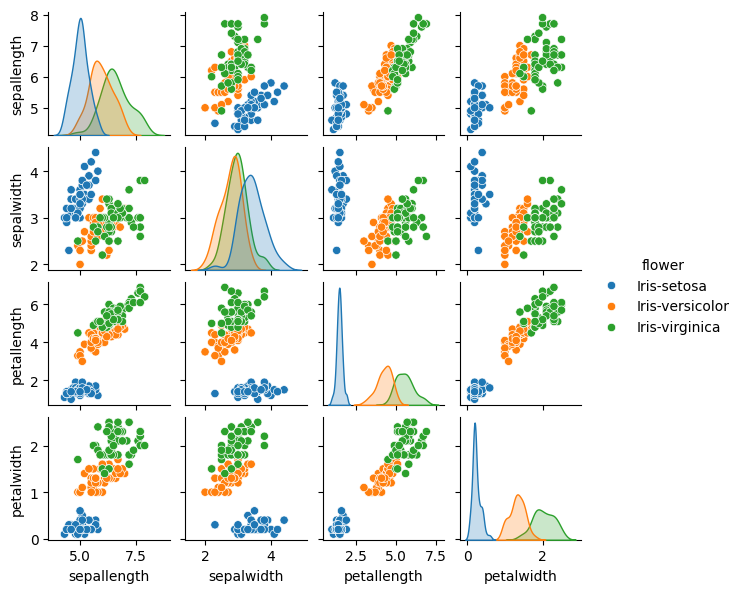

In [26]:
_ = seaborn.pairplot(iris, hue='flower', height=1.5)

# O PERCEPTRON 2D

Discriminando um tipo de Iris com apenas duas variáveis.

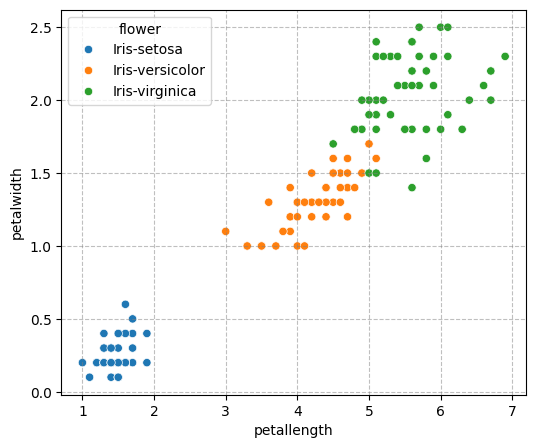

In [ ]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
_ = seaborn.scatterplot(iris, x='petallength', y='petalwidth', hue='flower', ax=ax)
_ = ax.grid(which='major', color='gray', linestyle='--', alpha=0.5)

In [7]:
class Perceptron:
    a : float
    b : float

    def __init__(self, v1, v2):
        self.a = (v2[1] - v1[1])/(v2[0] - v1[0])
        self.b = v2[1] - self.a*v2[0]

    def score(self, x):
        return self.a*x+self.b
    
    def predict(self, x):
        return self.a*x[0]+self.b - x[1]
    

## PARÂMETROS

In [31]:
my_iris = 'Iris-setosa'
my_step = 0.1
perceptron_attributes = ['petallength', 'petalwidth']
v1 = (2.0, 0.75)
v2 = (2.5, 0.5)
my_flower = (2.5, 0.75)

### Resultado

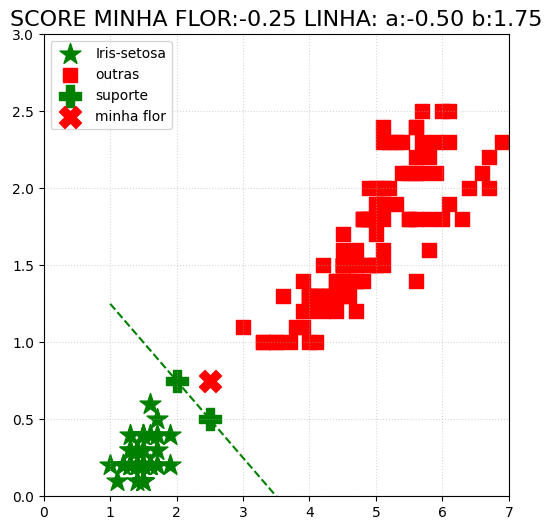

In [32]:
X = iris[perceptron_attributes].to_numpy()
Y = (iris['flower'] == my_iris).astype(float).to_numpy()

model = Perceptron(v1, v2)

x_n = numpy.arange(start=X[:, 0].min(), stop=X[:, 0].max(), step=my_step)
y_n = model.score(x_n)
y_p = model.predict(my_flower)

if y_p > 0:
    my_flower_color = 'green'
else:
    my_flower_color = 'red'


fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
_ = ax.scatter(X[Y == 1, 0], X[Y == 1, 1], s=250, label=my_iris, color='green', marker='*')
_ = ax.scatter(X[Y == 0, 0], X[Y == 0, 1], s=100, label='outras', color = 'red', marker='s')
_ = ax.plot(x_n, y_n, color='green', ls='--')
_ = ax.scatter([v1[0], v2[0]], [v1[1], v2[1]], s=250, label='suporte', color = 'green', marker='P')
_ = ax.scatter(my_flower[0], my_flower[1], s=250, label='minha flor', color = my_flower_color, marker = 'X')
_ = ax.set_xlim([0, 7])
_ = ax.set_ylim([0, 3])
_ = ax.legend()
_ = ax.grid(which='both', ls=':', alpha=0.5)
_ = ax.set_title('SCORE MINHA FLOR:{:.2f} LINHA: a:{:.2f} b:{:.2f}'.format(y_p, model.a, model.b), size=16)